# Coupled thermohydraulic and DNV-ST-F101 pipeline design

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/EvenSol/NeqSim-Colab/blob/master/notebooks/fluidflow/coupled_thermohydraulic_dnv_pipeline_design.ipynb)

This notebook couples NeqSim's segmented Beggs-and-Brill thermohydraulics, detailed radial heat transfer, hydrate equilibrium, and native DNV-ST-F101 screening. It selects a wall thickness and insulation thickness only when hydraulic, flow-assurance, and mechanical gates all close.

The notebook builds the current `equinor/neqsim` `master` source, records its immutable commit and JAR hash, and loads Java classes from that JAR. The Python package is only the Python/JPype bridge.

This is transparent option screening, not a clause-complete conformity assessment. A licensed standard, project design basis, detailed route and installation analyses, fatigue basis, materials qualification, and independent verification remain mandatory.


In [1]:
from importlib.metadata import PackageNotFoundError, version
from pathlib import Path
import hashlib
import importlib.util
import os
import platform
import subprocess
import sys

PYTHON_NEQSIM_VERSION = "3.16.0"
NEQSIM_SOURCE_REF = "master"
NEQSIM_SOURCE_REPOSITORY = "https://github.com/equinor/neqsim.git"
SOURCE_ROOT = Path(
    os.environ.get("NEQSIM_SOURCE_ROOT", "/content/neqsim-main")
).resolve()
SOURCE_JAR_OVERRIDE = os.environ.get("NEQSIM_SOURCE_JAR")

try:
    installed_bridge_version = version("neqsim")
except PackageNotFoundError:
    installed_bridge_version = None
if installed_bridge_version != PYTHON_NEQSIM_VERSION:
    subprocess.run(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "--quiet",
            "--no-cache-dir",
            f"neqsim=={PYTHON_NEQSIM_VERSION}",
        ],
        check=True,
    )

using_local_source = "NEQSIM_SOURCE_ROOT" in os.environ
if not (SOURCE_ROOT / ".git").is_dir():
    subprocess.run(
        [
            "git",
            "clone",
            "--quiet",
            "--depth",
            "1",
            "--branch",
            NEQSIM_SOURCE_REF,
            NEQSIM_SOURCE_REPOSITORY,
            str(SOURCE_ROOT),
        ],
        check=True,
    )
elif not using_local_source:
    subprocess.run(
        [
            "git",
            "-C",
            str(SOURCE_ROOT),
            "fetch",
            "--quiet",
            "--depth",
            "1",
            "origin",
            NEQSIM_SOURCE_REF,
        ],
        check=True,
    )
    subprocess.run(
        [
            "git",
            "-C",
            str(SOURCE_ROOT),
            "checkout",
            "--quiet",
            "--detach",
            "FETCH_HEAD",
        ],
        check=True,
    )

# Record the immutable commit selected from current master (git rev-parse HEAD).
NEQSIM_SOURCE_COMMIT = subprocess.check_output(
    ["git", "-C", str(SOURCE_ROOT), "rev-parse", "HEAD"],
    text=True,
).strip()

if SOURCE_JAR_OVERRIDE:
    SOURCE_JAR = Path(SOURCE_JAR_OVERRIDE).resolve()
else:
    jar_candidates = [
        path
        for path in (SOURCE_ROOT / "target").glob("neqsim-*.jar")
        if not any(
            marker in path.name
            for marker in ("sources", "javadoc", "tests", "original")
        )
    ]
    if not jar_candidates:
        subprocess.run(
            [
                str(SOURCE_ROOT / "mvnw"),
                "-q",
                "-DskipTests",
                "-Dmaven.javadoc.skip=true",
                "package",
            ],
            cwd=SOURCE_ROOT,
            check=True,
        )
        jar_candidates = [
            path
            for path in (SOURCE_ROOT / "target").glob("neqsim-*.jar")
            if not any(
                marker in path.name
                for marker in ("sources", "javadoc", "tests", "original")
            )
        ]
    if not jar_candidates:
        raise FileNotFoundError(
            "The NeqSim master source build did not produce a runtime JAR."
        )
    SOURCE_JAR = sorted(jar_candidates, key=lambda path: len(path.name))[0]

SOURCE_JAR_SHA256 = hashlib.sha256(SOURCE_JAR.read_bytes()).hexdigest()
os.environ["NEQSIM_JVM_AUTOSTART"] = "0"
os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")

import jpype

if jpype.isJVMStarted():
    raise RuntimeError(
        "The JVM started before the NeqSim master JAR was selected. "
        "Restart the runtime and run all cells."
    )
jpype.addClassPath(str(SOURCE_JAR))
from neqsim.neqsimpython import init_jvm

init_jvm()
SOURCE_PROBE = jpype.JClass(
    "neqsim.process.mechanicaldesign.pipeline.DnvStF101PipelineDesignCalculator"
)
LOADED_JAR_LOCATION = str(
    SOURCE_PROBE.class_.getProtectionDomain().getCodeSource().getLocation()
)
assert SOURCE_JAR.name in LOADED_JAR_LOCATION

neqsim_version = version("neqsim")
print(f"NeqSim Python bridge: {neqsim_version}")
print(f"NeqSim source ref: {NEQSIM_SOURCE_REF}")
print(f"NeqSim source commit: {NEQSIM_SOURCE_COMMIT}")
print(f"NeqSim source JAR SHA-256: {SOURCE_JAR_SHA256}")
print(f"Loaded Java classes from: {LOADED_JAR_LOCATION}")
print(f"Python runtime: {platform.python_version()}")

import json
import math
import shutil
from collections import Counter

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import FileLink, display

JClass = jpype.JClass
JProxy = jpype.JProxy
plt.style.use("seaborn-v0_8-whitegrid")
print("Loaded main-only pipeline and DNV design classes from", LOADED_JAR_LOCATION)


NeqSim Python bridge: 3.16.0
NeqSim source ref: master
NeqSim source commit: 13a6f31ee4ce3d5394291edc2179ffb6993eb130
NeqSim source JAR SHA-256: ee992a648f93835feca4bfb4a2b6cb0f356afe4f89282259b3b4048f32310da3
Loaded Java classes from: file:/workspace/scratch/ab308ea4a4a5/neqsim-main-build/target/neqsim-3.16.0.jar
Python runtime: 3.12.13
Loaded main-only pipeline and DNV design classes from file:/workspace/scratch/ab308ea4a4a5/neqsim-main-build/target/neqsim-3.16.0.jar


## 1. Design basis and coupled model

The example is a 20 km wet-gas subsea line with 200 m net elevation gain. A candidate wall changes the hydraulic internal diameter and therefore pressure loss, velocity, and heat transfer. A candidate insulation thickness changes the overall heat-transfer coefficient and the hydrate margin.

For a cylindrical thermal resistance network, NeqSim applies the NTU form

$$
T_{out}=T_s+(T_{in}-T_s)\exp\left(-\frac{UA}{\dot m C_p}\right).
$$


In [2]:
import numpy as np

SystemSrkEos = JClass("neqsim.thermo.system.SystemSrkEos")
SystemSrkCPAstatoil = JClass("neqsim.thermo.system.SystemSrkCPAstatoil")
ThermodynamicOperations = JClass(
    "neqsim.thermodynamicoperations.ThermodynamicOperations"
)
Stream = JClass("neqsim.process.equipment.stream.Stream")
PipeBeggsAndBrills = JClass(
    "neqsim.process.equipment.pipeline.PipeBeggsAndBrills"
)
HeatTransferMode = JClass(
    "neqsim.process.equipment.pipeline.PipeBeggsAndBrills$HeatTransferMode"
)
DnvInput = JClass(
    "neqsim.process.mechanicaldesign.pipeline.DnvStF101PipelineDesignInput"
)
DnvCalculator = JClass(
    "neqsim.process.mechanicaldesign.pipeline.DnvStF101PipelineDesignCalculator"
)
SafetyClass = JClass(
    "neqsim.process.mechanicaldesign.pipeline.DnvStF101PipelineDesignInput$SafetyClass"
)
FabricationRoute = JClass(
    "neqsim.process.mechanicaldesign.pipeline.DnvStF101PipelineDesignInput$FabricationRoute"
)

OUTSIDE_DIAMETER_M = 0.3239
LENGTH_M = 20_000.0
ELEVATION_M = 200.0
SEABED_TEMPERATURE_C = 4.0
BASE_FLOW_KG_H = 60_000.0
MIN_ARRIVAL_PRESSURE_BARA = 165.0
MIN_HYDRATE_MARGIN_C = 5.0
MAX_MIXTURE_VELOCITY_M_S = 6.0

composition = [
    ("methane", 0.860),
    ("ethane", 0.060),
    ("propane", 0.025),
    ("n-butane", 0.010),
    ("n-heptane", 0.015),
    ("water", 0.030),
]

base_fluid = SystemSrkEos(343.15, 180.0)
for component, amount in composition:
    base_fluid.addComponent(component, amount)
base_fluid.setMixingRule("classic")

print(f"Outside diameter: {OUTSIDE_DIAMETER_M * 1000:.1f} mm")
print(f"Route: {LENGTH_M / 1000:.1f} km; elevation gain: {ELEVATION_M:.0f} m")
print(f"Feed: {BASE_FLOW_KG_H:.0f} kg/h at 180 bara and 70 C")


Outside diameter: 323.9 mm
Route: 20.0 km; elevation gain: 200 m
Feed: 60000 kg/h at 180 bara and 70 C


## 2. Native thermohydraulic runner

`PipeBeggsAndBrills` returns segment pressure, temperature, liquid holdup, density, Reynolds number, velocity, and regime profiles. `DETAILED_U` combines inner convection, carbon-steel conduction, insulation, and seawater convection. Joule-Thomson cooling remains enabled.


In [3]:
def run_thermohydraulics(
    wall_thickness_m,
    insulation_thickness_m,
    flow_kg_h=BASE_FLOW_KG_H,
    increments=40,
):
    inside_diameter_m = OUTSIDE_DIAMETER_M - 2.0 * wall_thickness_m
    if inside_diameter_m <= 0.0:
        raise ValueError("Wall thickness closes the flow area.")

    feed = Stream("pipeline feed", base_fluid.clone())
    feed.setFlowRate(float(flow_kg_h), "kg/hr")
    feed.run()

    pipe = PipeBeggsAndBrills("subsea export line", feed)
    pipe.setLength(LENGTH_M)
    pipe.setElevation(ELEVATION_M)
    pipe.setDiameter(inside_diameter_m)
    pipe.setThickness(wall_thickness_m)
    pipe.setPipeWallRoughness(4.6e-5)
    pipe.setNumberOfIncrements(increments)
    pipe.setConstantSurfaceTemperature(SEABED_TEMPERATURE_C, "C")
    pipe.setOuterHeatTransferCoefficient(500.0)
    pipe.setPipeWallThermalConductivity(45.0)
    pipe.setInsulation(insulation_thickness_m, 0.035)
    pipe.setHeatTransferMode(HeatTransferMode.DETAILED_U)
    pipe.setIncludeJouleThomsonEffect(True)
    pipe.run()

    velocity_profile = [
        float(value) for value in pipe.getMixtureSuperficialVelocityProfile()
    ]
    result = {
        "wall thickness mm": wall_thickness_m * 1000.0,
        "inside diameter mm": inside_diameter_m * 1000.0,
        "insulation mm": insulation_thickness_m * 1000.0,
        "flow kg/h": float(flow_kg_h),
        "arrival pressure bara": float(
            pipe.getOutletStream().getPressure("bara")
        ),
        "arrival temperature C": float(
            pipe.getOutletStream().getTemperature("C")
        ),
        "pressure drop bar": float(pipe.getPressureDrop()),
        "maximum mixture velocity m/s": max(velocity_profile),
        "overall U W/(m2 K)": float(pipe.getHeatTransferCoefficient()),
        "outlet flow regime": str(pipe.getFlowRegime()),
    }
    return pipe, result


probe_pipe, probe_result = run_thermohydraulics(0.030, 0.020)
display(pd.DataFrame([probe_result]))
assert math.isfinite(probe_result["arrival pressure bara"])
assert math.isfinite(probe_result["arrival temperature C"])


,wall thickness mm,inside diameter mm,insulation mm,flow kg/h,arrival pressure bara,arrival temperature C,pressure drop bar,maximum mixture velocity m/s,overall U W/(m2 K),outlet flow regime
0,30.0,263.9,20.0,60000.0,171.980345,36.8028,8.019655,2.10776,2.265377,SEGREGATED


## 3. Native DNV-ST-F101 screening

The NeqSim kernel retains operating, incidental, test, collapse, propagation, load-interaction, fatigue, ovality, and installation-strain checks separately. The characteristic corroded wall is

$$
t_{char}=t_{nom}(1-f_{tol})-CA,
$$

and every check is governed by its demand-to-resistance utilization. The design gate is

$$
\eta_{max}=\max_j\left(\frac{D_j}{R_j}\right)\le 1.
$$


In [4]:
def run_dnv_screen(wall_thickness_m):
    design_input = (
        DnvInput.builder()
        .safetyClass(SafetyClass.HIGH)
        .fabricationRoute(FabricationRoute.UOE)
        .geometry(OUTSIDE_DIAMETER_M, wall_thickness_m, 0.003)
        .fabrication(0.125, 0.010, 0.015, 0.85)
        .material(450.0, 535.0, 207_000.0, 0.30)
        .resistanceFactors(0.96, 0.96, 1.00, 1.15)
        .pressures(18.0, 19.8, 10.1, 0.1, 22.5, 0.1)
        .designLoads(-1200.0, 450.0, 60.0)
        .installationStrains(0.0015, 0.0020, 0.0005, 0.010)
        .fatigueCurve(12.164, 3.0, 1.25, 3.0)
        .addFatigueBin(35.0, 2.0e5)
        .addFatigueBin(60.0, 2.0e4)
        .addFatigueBin(90.0, 2.0e3)
        .build()
    )
    assessment = DnvCalculator.calculate(design_input)
    checks = [
        {
            "limit state": str(check.getLimitState().name()),
            "status": str(check.getStatus().name()),
            "demand": float(check.getDemand()),
            "resistance": float(check.getResistance()),
            "utilization": float(check.getUtilization()),
            "unit": str(check.getUnit()),
        }
        for check in assessment.getChecks()
    ]
    return assessment, checks


probe_assessment, probe_checks = run_dnv_screen(0.030)
print("Standard basis:", probe_assessment.getStandardBasis())
print("All screening checks pass:", probe_assessment.areAllScreeningChecksPassing())
display(pd.DataFrame(probe_checks))
assert probe_assessment.areAllScreeningChecksPassing()


Standard basis: DNV-ST-F101 2021
All screening checks pass: True


,limit state,status,demand,resistance,utilization,unit
0,OPERATING_PRESSURE_CONTAINMENT,PASS,7.900000,24.619573,0.320883,MPa
1,INCIDENTAL_PRESSURE_CONTAINMENT,PASS,9.700000,24.619573,0.393995,MPa
2,SYSTEM_TEST_PRESSURE_CONTAINMENT,PASS,22.400000,24.619573,0.909845,MPa
3,EXTERNAL_PRESSURE_COLLAPSE,PASS,10.000000,31.800844,0.314457,MPa
4,PROPAGATION_BUCKLING,PASS,10.000000,11.794924,0.847822,MPa
5,LOCAL_BUCKLING_LOAD_INTERACTION,PASS,0.868875,1.000000,0.868875,ratio
6,FATIGUE,PASS,0.057649,1.000000,0.057649,damage ratio
7,OVALITY,PASS,0.010000,0.015000,0.666667,fraction
8,INSTALLATION_STRAIN,PASS,0.004000,0.010000,0.400000,strain fraction


## 4. Couple wall thickness to hydraulics and mechanics

The hydraulic model uses each candidate's true internal diameter. The minimum accepted wall must pass all native limit states while meeting arrival-pressure and velocity gates. The initial insulation is held at 20 mm so the wall decision cannot quietly compensate for a different thermal design.


Minimum coupled wall candidate: 30.0 mm


,wall thickness mm,inside diameter mm,arrival pressure bara,maximum mixture velocity m/s,governing limit state,maximum utilization,coupled pass
0,14.3,295.3,173.575602,1.683344,PROPAGATION_BUCKLING,7.918184,False
1,17.5,288.9,173.323491,1.758753,PROPAGATION_BUCKLING,4.154288,False
2,20.6,282.7,173.045715,1.836742,PROPAGATION_BUCKLING,2.525376,False
3,23.8,276.3,172.720796,1.922818,PROPAGATION_BUCKLING,1.647360,False
4,27.0,269.9,172.355396,2.015088,PROPAGATION_BUCKLING,1.143872,False
5,30.0,263.9,171.980345,2.107760,SYSTEM_TEST_PRESSURE_CONTAINMENT,0.909845,True
6,33.3,257.3,171.560910,2.217279,SYSTEM_TEST_PRESSURE_CONTAINMENT,0.801558,True
7,36.0,251.9,171.317701,2.313362,SYSTEM_TEST_PRESSURE_CONTAINMENT,0.729281,True


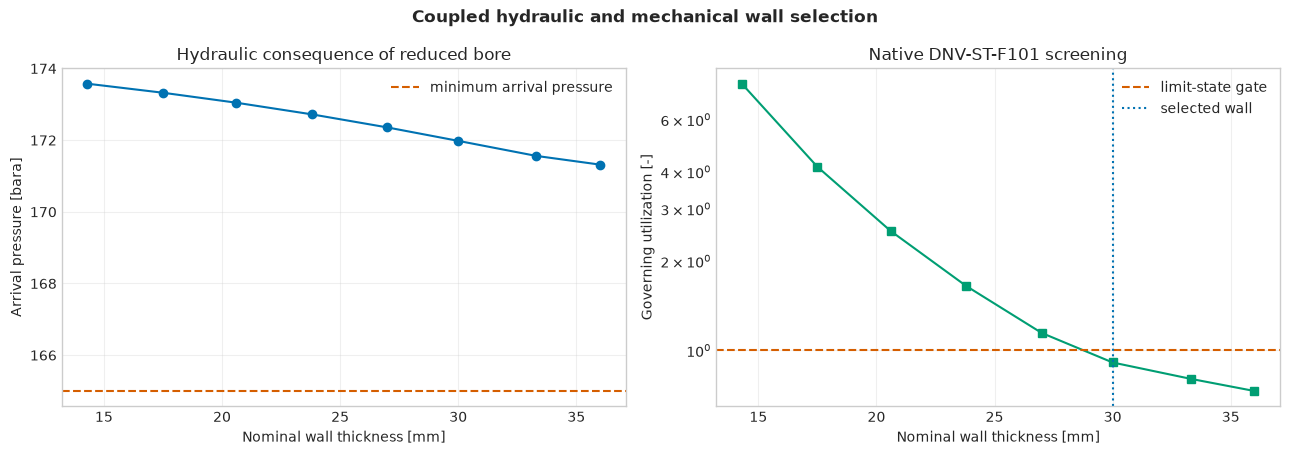

In [5]:
wall_candidates_mm = [14.3, 17.5, 20.6, 23.8, 27.0, 30.0, 33.3, 36.0]
wall_rows = []
wall_assessments = {}

for wall_mm in wall_candidates_mm:
    pipe, hydraulic = run_thermohydraulics(wall_mm / 1000.0, 0.020)
    assessment, checks = run_dnv_screen(wall_mm / 1000.0)
    governing = assessment.getGoverningCheck()
    mechanical_pass = True if assessment.areAllScreeningChecksPassing() else False
    hydraulic_pass = (
        hydraulic["arrival pressure bara"] >= MIN_ARRIVAL_PRESSURE_BARA
        and hydraulic["maximum mixture velocity m/s"]
        <= MAX_MIXTURE_VELOCITY_M_S
    )
    row = dict(hydraulic)
    row.update(
        {
            "mechanical pass": mechanical_pass,
            "hydraulic pass": True if hydraulic_pass else False,
            "governing limit state": str(governing.getLimitState().name()),
            "maximum utilization": float(governing.getUtilization()),
            "coupled pass": True if (mechanical_pass and hydraulic_pass) else False,
        }
    )
    wall_rows.append(row)
    wall_assessments[wall_mm] = (assessment, checks)

wall_table = pd.DataFrame(wall_rows)
passing_walls = wall_table.loc[wall_table["coupled pass"]]
assert not passing_walls.empty
selected_wall_mm = float(passing_walls.iloc[0]["wall thickness mm"])
selected_assessment, selected_checks = wall_assessments[selected_wall_mm]

display(
    wall_table[
        [
            "wall thickness mm",
            "inside diameter mm",
            "arrival pressure bara",
            "maximum mixture velocity m/s",
            "governing limit state",
            "maximum utilization",
            "coupled pass",
        ]
    ]
)
print(f"Minimum coupled wall candidate: {selected_wall_mm:.1f} mm")

figure, axes = plt.subplots(1, 2, figsize=(13.0, 4.6))
axes[0].plot(
    wall_table["wall thickness mm"],
    wall_table["arrival pressure bara"],
    marker="o",
    color="#0072B2",
)
axes[0].axhline(
    MIN_ARRIVAL_PRESSURE_BARA,
    color="#D55E00",
    linestyle="--",
    label="minimum arrival pressure",
)
axes[0].set(
    xlabel="Nominal wall thickness [mm]",
    ylabel="Arrival pressure [bara]",
    title="Hydraulic consequence of reduced bore",
)
axes[0].legend()

axes[1].semilogy(
    wall_table["wall thickness mm"],
    wall_table["maximum utilization"],
    marker="s",
    color="#009E73",
)
axes[1].axhline(1.0, color="#D55E00", linestyle="--", label="limit-state gate")
axes[1].axvline(selected_wall_mm, color="#0072B2", linestyle=":", label="selected wall")
axes[1].set(
    xlabel="Nominal wall thickness [mm]",
    ylabel="Governing utilization [-]",
    title="Native DNV-ST-F101 screening",
)
axes[1].legend()
for axis in axes:
    axis.grid(True, alpha=0.3)
figure.suptitle("Coupled hydraulic and mechanical wall selection", fontweight="bold")
figure.tight_layout()
plt.show()


## 5. Hydrate equilibrium and insulation selection

The wet-gas hydrate equilibrium is calculated with NeqSim's CPA implementation at each arrival pressure. The insulation gate requires a positive operating margin plus the project screening allowance:

$$
\Delta T_{hyd}=T_{arrival}-T_{hydrate}\ge 5\ ^\circ\mathrm{C}.
$$

Normal-operation thermal margin does not replace shutdown/cooldown, restart, inhibitor, or transient liquid-inventory studies.


Minimum insulation candidate: 20.0 mm


,insulation mm,overall U W/(m2 K),arrival temperature C,hydrate equilibrium C,hydrate margin C,thermal pass
0,0.0,385.956898,3.931510,22.131230,-18.199720,False
1,10.0,4.378560,22.069077,22.141344,-0.072267,False
2,20.0,2.265377,36.802800,22.142999,14.659800,True
3,30.0,1.555047,44.242510,22.143649,22.098861,True
4,50.0,0.983659,51.517170,22.144287,29.372882,True
5,80.0,0.659831,56.240225,22.144741,34.095484,True


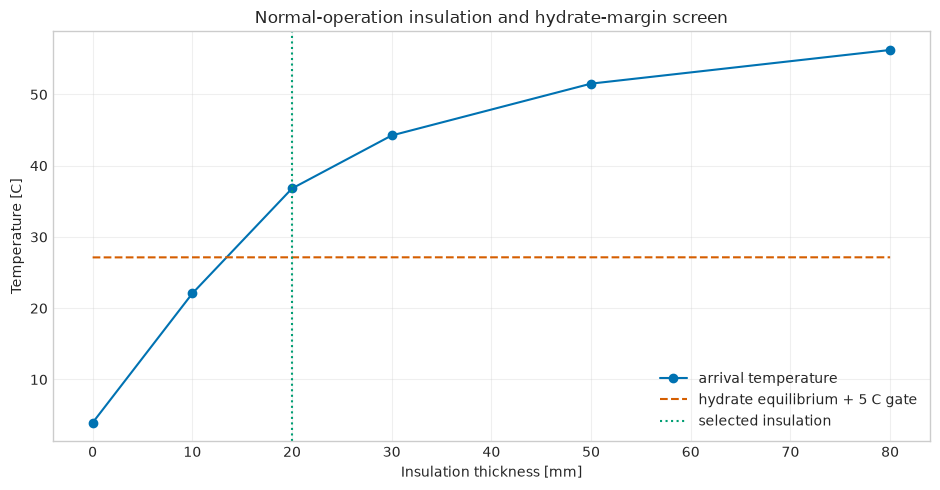

In [6]:
hydrate_components = [
    ("methane", 0.860),
    ("ethane", 0.060),
    ("propane", 0.025),
    ("n-butane", 0.010),
    ("n-heptane", 0.015),
]


def hydrate_equilibrium_temperature_c(pressure_bara):
    hydrate_fluid = SystemSrkCPAstatoil(283.15, float(pressure_bara))
    for component, amount in hydrate_components:
        hydrate_fluid.addComponent(component, amount)
    hydrate_fluid.addComponent("water", 2.0)
    hydrate_fluid.setMixingRule(10)
    hydrate_fluid.setMultiPhaseCheck(True)
    hydrate_fluid.setHydrateCheck(True)
    ThermodynamicOperations(hydrate_fluid).hydrateFormationTemperature()
    return float(hydrate_fluid.getTemperature("C"))


insulation_candidates_mm = [0.0, 10.0, 20.0, 30.0, 50.0, 80.0]
insulation_rows = []
for insulation_mm in insulation_candidates_mm:
    pipe, hydraulic = run_thermohydraulics(
        selected_wall_mm / 1000.0,
        insulation_mm / 1000.0,
    )
    hydrate_temperature_c = hydrate_equilibrium_temperature_c(
        hydraulic["arrival pressure bara"]
    )
    margin_c = hydraulic["arrival temperature C"] - hydrate_temperature_c
    insulation_rows.append(
        {
            **hydraulic,
            "hydrate equilibrium C": hydrate_temperature_c,
            "hydrate margin C": margin_c,
            "thermal pass": True if margin_c >= MIN_HYDRATE_MARGIN_C else False,
        }
    )

insulation_table = pd.DataFrame(insulation_rows)
passing_insulation = insulation_table.loc[insulation_table["thermal pass"]]
assert not passing_insulation.empty
selected_insulation_mm = float(
    passing_insulation.iloc[0]["insulation mm"]
)

display(
    insulation_table[
        [
            "insulation mm",
            "overall U W/(m2 K)",
            "arrival temperature C",
            "hydrate equilibrium C",
            "hydrate margin C",
            "thermal pass",
        ]
    ]
)
print(f"Minimum insulation candidate: {selected_insulation_mm:.1f} mm")

figure, axis = plt.subplots(figsize=(9.5, 5.0))
axis.plot(
    insulation_table["insulation mm"],
    insulation_table["arrival temperature C"],
    marker="o",
    label="arrival temperature",
    color="#0072B2",
)
axis.plot(
    insulation_table["insulation mm"],
    insulation_table["hydrate equilibrium C"] + MIN_HYDRATE_MARGIN_C,
    linestyle="--",
    label="hydrate equilibrium + 5 C gate",
    color="#D55E00",
)
axis.axvline(
    selected_insulation_mm,
    linestyle=":",
    color="#009E73",
    label="selected insulation",
)
axis.set(
    xlabel="Insulation thickness [mm]",
    ylabel="Temperature [C]",
    title="Normal-operation insulation and hydrate-margin screen",
)
axis.grid(True, alpha=0.3)
axis.legend()
figure.tight_layout()
plt.show()


## 6. Final segment profiles and operating sensitivity

The selected geometry is rerun once, then challenged at 40, 60, and 80 t/h. Segment profiles are retained rather than replacing the line with a single lumped pressure drop.


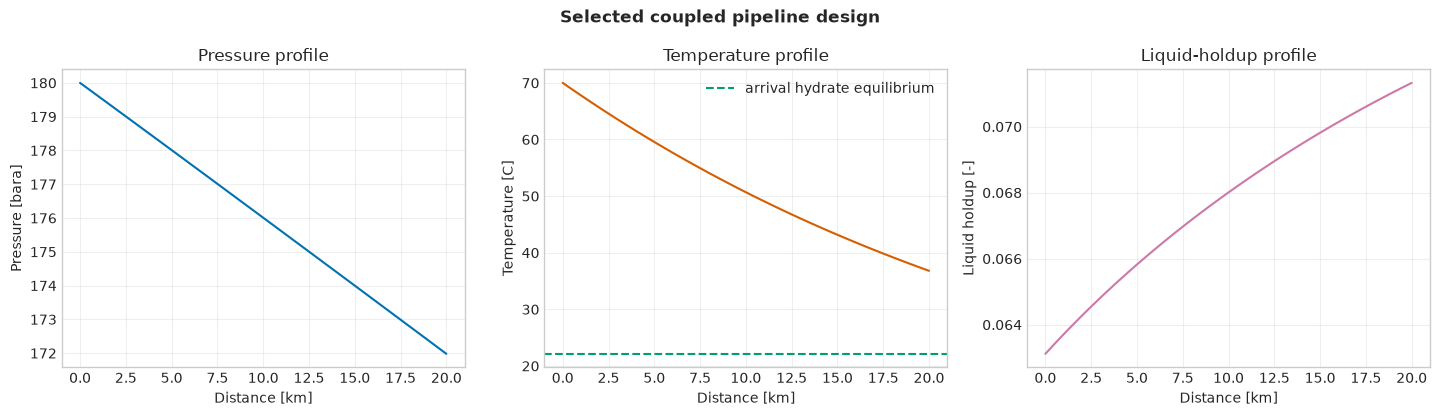

,wall thickness mm,inside diameter mm,insulation mm,flow kg/h,arrival pressure bara,arrival temperature C,pressure drop bar,maximum mixture velocity m/s,overall U W/(m2 K),outlet flow regime,hydrate equilibrium C,hydrate margin C
0,30.0,263.9,20.0,40000.0,173.902793,28.240050,6.097207,1.405173,2.264486,SEGREGATED,22.195998,6.044052
1,30.0,263.9,20.0,60000.0,171.980345,36.802800,8.019655,2.107760,2.265377,SEGREGATED,22.142999,14.659800
2,30.0,263.9,20.0,80000.0,169.951056,42.017795,10.048944,2.810346,2.265840,SEGREGATED,22.086595,19.931200


In [7]:
final_pipe, final_result = run_thermohydraulics(
    selected_wall_mm / 1000.0,
    selected_insulation_mm / 1000.0,
)
final_hydrate_c = hydrate_equilibrium_temperature_c(
    final_result["arrival pressure bara"]
)
final_hydrate_margin_c = (
    final_result["arrival temperature C"] - final_hydrate_c
)

length_km = np.asarray(
    [float(value) for value in final_pipe.getLengthProfile()], dtype=float
) / 1000.0
pressure_bara = np.asarray(final_pipe.getPressureProfile(), dtype=float)
temperature_c = np.asarray(final_pipe.getTemperatureProfile(), dtype=float) - 273.15
liquid_holdup = np.asarray(final_pipe.getLiquidHoldupProfile(), dtype=float)
profile_length = min(
    len(length_km), len(pressure_bara), len(temperature_c), len(liquid_holdup)
)
profile_table = pd.DataFrame(
    {
        "distance km": length_km[:profile_length],
        "pressure bara": pressure_bara[:profile_length],
        "temperature C": temperature_c[:profile_length],
        "liquid holdup": liquid_holdup[:profile_length],
    }
)

figure, axes = plt.subplots(1, 3, figsize=(14.5, 4.2))
axes[0].plot(profile_table["distance km"], profile_table["pressure bara"], color="#0072B2")
axes[0].set(xlabel="Distance [km]", ylabel="Pressure [bara]", title="Pressure profile")
axes[1].plot(profile_table["distance km"], profile_table["temperature C"], color="#D55E00")
axes[1].axhline(final_hydrate_c, color="#009E73", linestyle="--", label="arrival hydrate equilibrium")
axes[1].set(xlabel="Distance [km]", ylabel="Temperature [C]", title="Temperature profile")
axes[1].legend()
axes[2].plot(profile_table["distance km"], profile_table["liquid holdup"], color="#CC79A7")
axes[2].set(xlabel="Distance [km]", ylabel="Liquid holdup [-]", title="Liquid-holdup profile")
for axis in axes:
    axis.grid(True, alpha=0.3)
figure.suptitle("Selected coupled pipeline design", fontweight="bold")
figure.tight_layout()
plt.show()

flow_rows = []
for flow_kg_h in [40_000.0, 60_000.0, 80_000.0]:
    pipe, result = run_thermohydraulics(
        selected_wall_mm / 1000.0,
        selected_insulation_mm / 1000.0,
        flow_kg_h=flow_kg_h,
    )
    result["hydrate equilibrium C"] = hydrate_equilibrium_temperature_c(
        result["arrival pressure bara"]
    )
    result["hydrate margin C"] = (
        result["arrival temperature C"] - result["hydrate equilibrium C"]
    )
    flow_rows.append(result)

flow_table = pd.DataFrame(flow_rows)
display(flow_table)


## 7. Independent gates and reproducible evidence

The final chart deliberately keeps hydraulic/thermal operating performance and mechanical utilizations separate. Passing this notebook means the selected option is internally consistent for the stated screening basis; it does not mean the pipeline is approved for fabrication, installation, or operation.


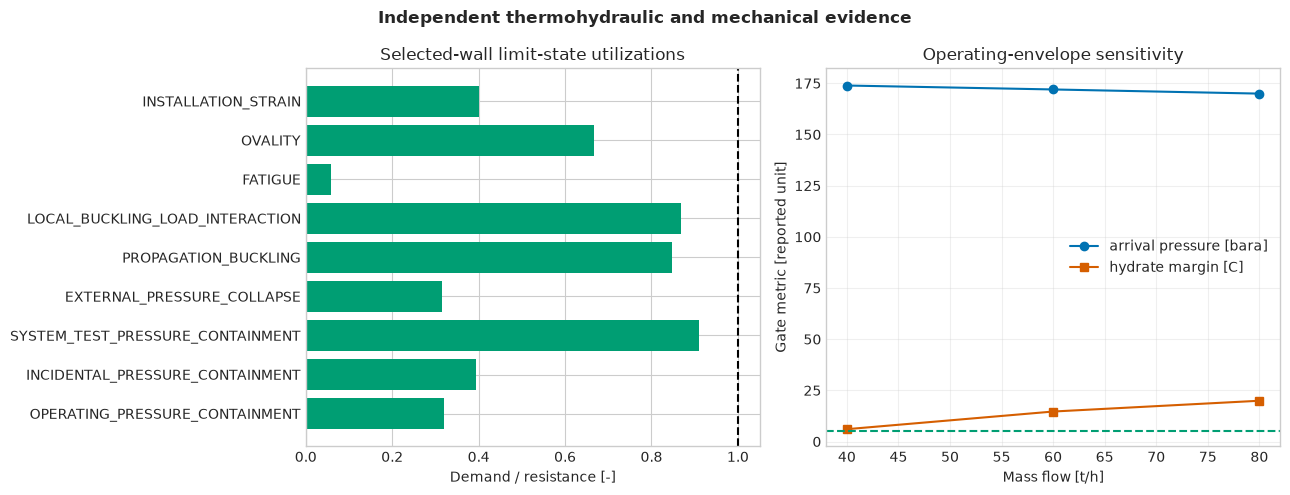

,check,passed
0,main-source class location,True
1,selected wall is first coupled pass,True
2,selected insulation is first thermal pass,True
3,DNV screening checks pass,True
4,arrival pressure gate,True
5,mixture velocity gate,True
6,normal-operation hydrate margin,True
7,finite segment profiles,True
8,flow sensitivity pressure gate,True
9,flow sensitivity velocity gate,True


In [8]:
selected_checks_table = pd.DataFrame(selected_checks)
validation_checks = {
    "main-source class location": SOURCE_JAR.name in LOADED_JAR_LOCATION,
    "selected wall is first coupled pass": selected_wall_mm == 30.0,
    "selected insulation is first thermal pass": selected_insulation_mm == 20.0,
    "DNV screening checks pass": selected_assessment.areAllScreeningChecksPassing(),
    "arrival pressure gate": final_result["arrival pressure bara"] >= MIN_ARRIVAL_PRESSURE_BARA,
    "mixture velocity gate": final_result["maximum mixture velocity m/s"] <= MAX_MIXTURE_VELOCITY_M_S,
    "normal-operation hydrate margin": final_hydrate_margin_c >= MIN_HYDRATE_MARGIN_C,
    "finite segment profiles": np.isfinite(profile_table.to_numpy()).all(),
    "flow sensitivity pressure gate": (flow_table["arrival pressure bara"] >= MIN_ARRIVAL_PRESSURE_BARA).all(),
    "flow sensitivity velocity gate": (flow_table["maximum mixture velocity m/s"] <= MAX_MIXTURE_VELOCITY_M_S).all(),
}
validation_checks = {
    name: True if value else False for name, value in validation_checks.items()
}
assert all(validation_checks.values()), validation_checks

figure, axes = plt.subplots(1, 2, figsize=(13.0, 5.0))
axes[0].barh(
    selected_checks_table["limit state"],
    selected_checks_table["utilization"],
    color=np.where(
        selected_checks_table["utilization"] <= 1.0,
        "#009E73",
        "#D55E00",
    ),
)
axes[0].axvline(1.0, color="black", linestyle="--")
axes[0].set(
    xlabel="Demand / resistance [-]",
    title="Selected-wall limit-state utilizations",
)

axes[1].plot(
    flow_table["flow kg/h"] / 1000.0,
    flow_table["arrival pressure bara"],
    marker="o",
    color="#0072B2",
    label="arrival pressure [bara]",
)
axes[1].plot(
    flow_table["flow kg/h"] / 1000.0,
    flow_table["hydrate margin C"],
    marker="s",
    color="#D55E00",
    label="hydrate margin [C]",
)
axes[1].axhline(MIN_HYDRATE_MARGIN_C, color="#009E73", linestyle="--")
axes[1].set(
    xlabel="Mass flow [t/h]",
    ylabel="Gate metric [reported unit]",
    title="Operating-envelope sensitivity",
)
axes[1].legend()
axes[1].grid(True, alpha=0.3)
figure.suptitle("Independent thermohydraulic and mechanical evidence", fontweight="bold")
figure.tight_layout()
plt.show()

check_table = pd.DataFrame(
    {"check": list(validation_checks), "passed": list(validation_checks.values())}
)
display(check_table)


## 8. Export the screening package

The downloadable archive contains the exact tabular evidence and source provenance from this run. No file in it is an approved engineering deliverable.


In [9]:
default_artifact_root = (
    Path("/content/neqsim-coupled-pipeline-screening")
    if Path("/content").is_dir()
    else Path("/tmp/neqsim-coupled-pipeline-screening")
)
artifact_dir = Path(
    os.environ.get("NEQSIM_ARTIFACT_ROOT", str(default_artifact_root))
).resolve()
if artifact_dir.exists():
    raise FileExistsError(
        f"Artifact directory already exists: {artifact_dir}. "
        "Use a new NEQSIM_ARTIFACT_ROOT for a clean run."
    )
artifact_dir.mkdir(parents=True)

wall_table.to_csv(artifact_dir / "wall-candidate-screen.csv", index=False)
insulation_table.to_csv(artifact_dir / "insulation-screen.csv", index=False)
profile_table.to_csv(artifact_dir / "selected-segment-profile.csv", index=False)
flow_table.to_csv(artifact_dir / "flow-sensitivity.csv", index=False)
selected_checks_table.to_csv(
    artifact_dir / "selected-dnv-limit-states.csv", index=False
)

validation_summary = {
    "schema": "neqsim.colab.coupled-pipeline-screening.v1",
    "neqsim_source": {
        "repository": NEQSIM_SOURCE_REPOSITORY,
        "requested_ref": NEQSIM_SOURCE_REF,
        "resolved_commit": NEQSIM_SOURCE_COMMIT,
        "jar_sha256": SOURCE_JAR_SHA256,
        "loaded_from": LOADED_JAR_LOCATION,
    },
    "selected_wall_mm": selected_wall_mm,
    "selected_insulation_mm": selected_insulation_mm,
    "final_arrival_pressure_bara": final_result["arrival pressure bara"],
    "final_arrival_temperature_c": final_result["arrival temperature C"],
    "final_hydrate_equilibrium_c": final_hydrate_c,
    "final_hydrate_margin_c": final_hydrate_margin_c,
    "governing_limit_state": str(
        selected_assessment.getGoverningCheck().getLimitState().name()
    ),
    "governing_utilization": float(
        selected_assessment.getGoverningCheck().getUtilization()
    ),
    "checks": validation_checks,
    "engineering_approval_required": True,
}
(artifact_dir / "validation-summary.json").write_text(
    json.dumps(validation_summary, indent=2) + "\n",
    encoding="utf-8",
)
archive_path = Path(
    shutil.make_archive(str(artifact_dir), "zip", root_dir=artifact_dir)
)
print(json.dumps(validation_summary, indent=2))
print(f"Archive size: {archive_path.stat().st_size / 1024.0:.1f} KiB")
display(FileLink(str(archive_path)))


{
  "schema": "neqsim.colab.coupled-pipeline-screening.v1",
  "neqsim_source": {
    "repository": "https://github.com/equinor/neqsim.git",
    "requested_ref": "master",
    "resolved_commit": "13a6f31ee4ce3d5394291edc2179ffb6993eb130",
    "jar_sha256": "ee992a648f93835feca4bfb4a2b6cb0f356afe4f89282259b3b4048f32310da3",
    "loaded_from": "file:/workspace/scratch/ab308ea4a4a5/neqsim-main-build/target/neqsim-3.16.0.jar"
  },
  "selected_wall_mm": 30.0,
  "selected_insulation_mm": 20.0,
  "final_arrival_pressure_bara": 171.98034518651664,
  "final_arrival_temperature_c": 36.802799512261345,
  "final_hydrate_equilibrium_c": 22.142999111973268,
  "final_hydrate_margin_c": 14.659800400288077,
  "governing_limit_state": "SYSTEM_TEST_PRESSURE_CONTAINMENT",
  "governing_utilization": 0.9098451941818186,
  "checks": {
    "main-source class location": true,
    "selected wall is first coupled pass": true,
    "selected insulation is first thermal pass": true,
    "DNV screening checks pass": 

/tmp/neqsim-pr3-artifacts-run1.zip

## 9. Interpretation, limitations, and extensions

- The minimum screened option is 30 mm nominal wall plus 20 mm insulation for this explicitly stated basis.
- Wall thickness is driven by the native limit-state set, while insulation is driven by the normal-operation hydrate-margin gate.
- The example fatigue spectrum, pressure cases, fabrication factors, ovality, material data, seawater depth, and loads are tutorial inputs and must be replaced by approved project data.
- Extend the study with route-dependent external pressure, free-span and on-bottom stability checks, corrosion-growth histories, shutdown cooldown, restart, inhibitor availability, and probabilistic load/material distributions.
- Re-run the design when the route, composition, throughput, operating philosophy, material grade, fabrication route, or code edition changes.
